<a href="https://colab.research.google.com/github/KaRaMbIIt/Mineria_De_Datos_VideoGameSales/blob/main/Ev_1_Mineria_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 1: Minería de Datos

**Asignatura:** BIY7121 Minería de Datos  
**Tema:** Análisis exploratorio de ventas de videojuegos  
**Integrantes:** Thomas Alexander Leighton Nuñez - Felipe Tapia  
**Fuente del dataset:** Video Game Sales



## Introducción

En este trabajo se realiza un análisis exploratorio de un conjunto de datos sobre ventas de videojuegos.  
La idea es revisar la estructura de la base, identificar el tipo de variables que contiene, detectar datos faltantes y observar algunos patrones generales en las ventas por género, plataforma y año.

El análisis se desarrolla con herramientas vistas en clases, llegando hasta la matriz de correlación. En cada parte se incluye una breve justificación del procedimiento y una interpretación de los resultados obtenidos.

## Sección 1: Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

print('✅ Librerías importadas')

✅ Librerías importadas


## Sección 2: Carga del dataset

In [ ]:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/sample_data/vgsales.csv', encoding='latin-1')

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
display(df.head())

Filas: 16,598 | Columnas: 11


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


> Cada fila es un videojuego. Las ventas están expresadas en **millones de copias**. `Global_Sales` es la suma de todas las regiones y será la variable que intentaremos predecir.

## Sección 3: Mapeo de datos

In [ ]:
mapeo = pd.DataFrame({
    'Columna'         : ['Rank','Name','Platform','Year','Genre',
                         'Publisher','NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales'],
    'Tipo Estadístico': ['Numérica','Categórica','Categórica','Numérica','Categórica',
                         'Categórica','Numérica','Numérica','Numérica','Numérica','Numérica'],
    'Tipo Informático': ['int64','object','object','float64','object',
                         'object','float64','float64','float64','float64','float64'],
    'Descripción': [
        'Ranking por ventas globales',
        'Nombre del videojuego',
        'Consola (PS4, Wii, DS, X360...)',
        'Año de lanzamiento',
        'Género (Action, Sports, RPG...)',
        'Empresa que publicó el juego',
        'Ventas Norteamérica (millones)',
        'Ventas Europa (millones)',
        'Ventas Japón (millones)',
        'Ventas resto del mundo (millones)',
        ' Ventas globales — Variable objetivo'
    ]
})
display(mapeo)

,Columna,Tipo Estadístico,Tipo Informático,Descripción
0,Rank,Numérica,int64,Ranking por ventas globales
1,Name,Categórica,object,Nombre del videojuego
2,Platform,Categórica,object,"Consola (PS4, Wii, DS, X360...)"
3,Year,Numérica,float64,Año de lanzamiento
4,Genre,Categórica,object,"Género (Action, Sports, RPG...)"
5,Publisher,Categórica,object,Empresa que publicó el juego
6,NA_Sales,Numérica,float64,Ventas Norteamérica (millones)
7,EU_Sales,Numérica,float64,Ventas Europa (millones)
8,JP_Sales,Numérica,float64,Ventas Japón (millones)
9,Other_Sales,Numérica,float64,Ventas resto del mundo (millones)


> `Year` aparece como `float64` en vez de entero porque tiene valores nulos — cuando una columna numérica tiene NaN, pandas la convierte automáticamente a decimal.

## Sección 4: Tipos de datos

In [ ]:
# object  = texto / categórico
# int64   = número entero
# float64 = número decimal
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
cols_num = df.select_dtypes(include=['int64','float64']).columns.tolist()
cols_cat = df.select_dtypes(include='object').columns.tolist()

print('Numéricas  :', cols_num)
print('Categóricas:', cols_cat)

Numéricas  : ['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Categóricas: ['Name', 'Platform', 'Genre', 'Publisher']


## Sección 5: Estadísticas descriptivas

In [ ]:
# mean = promedio | std = desviación estándar | 50% = mediana
display(df.describe())

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
# top = valor más frecuente | freq = cuántas veces aparece
display(df.describe(include='object'))

,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


> El juego promedio vende ~0.54 millones de copias, pero la mediana es solo ~0.17 millones. Esto significa que la mayoría de los juegos vende poco y unos pocos blockbusters concentran las grandes ventas. El género más frecuente es **Action** y el publisher con más títulos es **Electronic Arts**.

## Sección 6: Valores nulos antes y despues

In [ ]:
nulos_antes = pd.DataFrame({
    'Columna': df.columns,
    'Valores nulos': df.isnull().sum().values,
    'Porcentaje (%)': ((df.isnull().sum() / len(df)) * 100).round(2).values
})

display(nulos_antes)

,Columna,Valores nulos,Porcentaje (%)
0,Rank,0,0.00
1,Name,0,0.00
2,Platform,0,0.00
3,Year,271,1.63
4,Genre,0,0.00
5,Publisher,58,0.35
6,NA_Sales,0,0.00
7,EU_Sales,0,0.00
8,JP_Sales,0,0.00
9,Other_Sales,0,0.00


In [ ]:
# Year → mediana (variable numérica)
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Year'] = df['Year'].astype(int)

# Publisher → 'Desconocido' (variable categórica)
df['Publisher'] = df['Publisher'].fillna('Desconocido')

print(f'Nulos restantes: {df.isnull().sum().sum()}')

Nulos restantes: 0


In [ ]:
nulos_despues = pd.DataFrame({
    'Columna': df.columns,
    'Valores nulos': df.isnull().sum().values,
    'Porcentaje (%)': ((df.isnull().sum() / len(df)) * 100).round(2).values
})

display(nulos_despues)

,Columna,Valores nulos,Porcentaje (%)
0,Rank,0,0.0
1,Name,0,0.0
2,Platform,0,0.0
3,Year,0,0.0
4,Genre,0,0.0
5,Publisher,0,0.0
6,NA_Sales,0,0.0
7,EU_Sales,0,0.0
8,JP_Sales,0,0.0
9,Other_Sales,0,0.0


Solo Year (1,6%) y Publisher (0,35%) tenían valores nulos. En Year se usó la mediana porque es una variable numérica, y en Publisher se reemplazó por “Desconocido” porque es una variable categórica.

Los outliers corresponden a juegos con ventas muy altas, como Wii Sports o GTA V. No se consideran errores, por lo que se decidió mantenerlos.

## Sección 7: Análisis exploratorio

### Gráfico 1: Ventas totales por Género

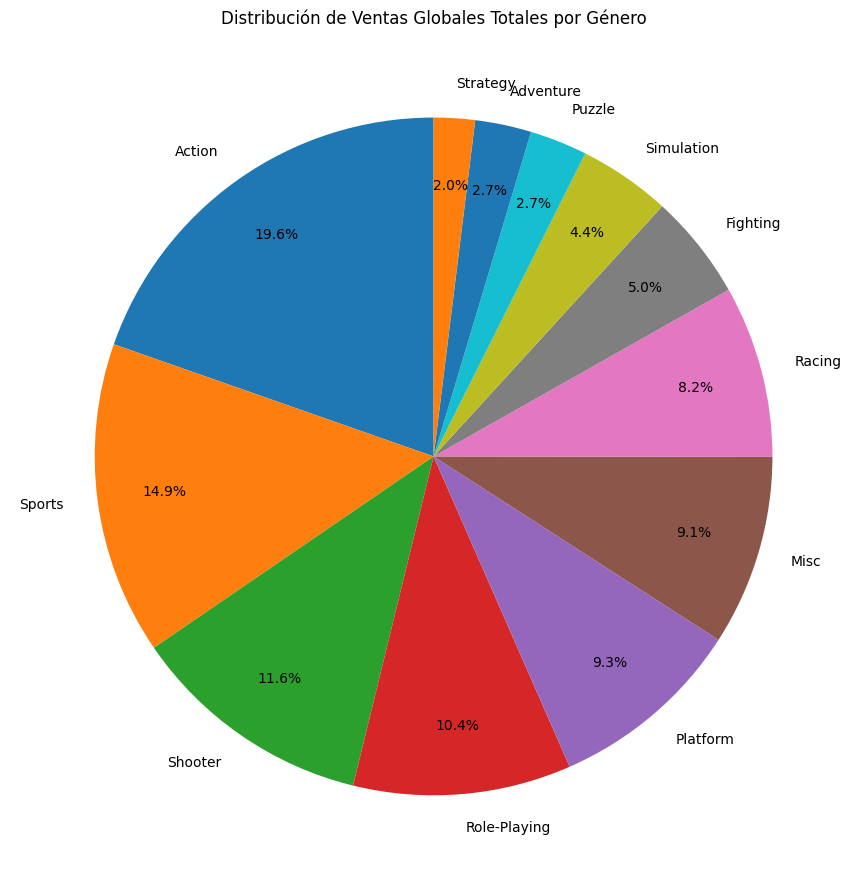

In [ ]:
ventas_genero = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(
    ventas_genero.values,
    labels=ventas_genero.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)
plt.title('Distribución de Ventas Globales Totales por Género')
plt.tight_layout()
plt.show()

> **Action** es el género con más ventas totales, seguido de **Sports** y **Shooter**. Son los géneros más producidos y consumidos a nivel global.

### Gráfico 2: Top 10 Plataformas

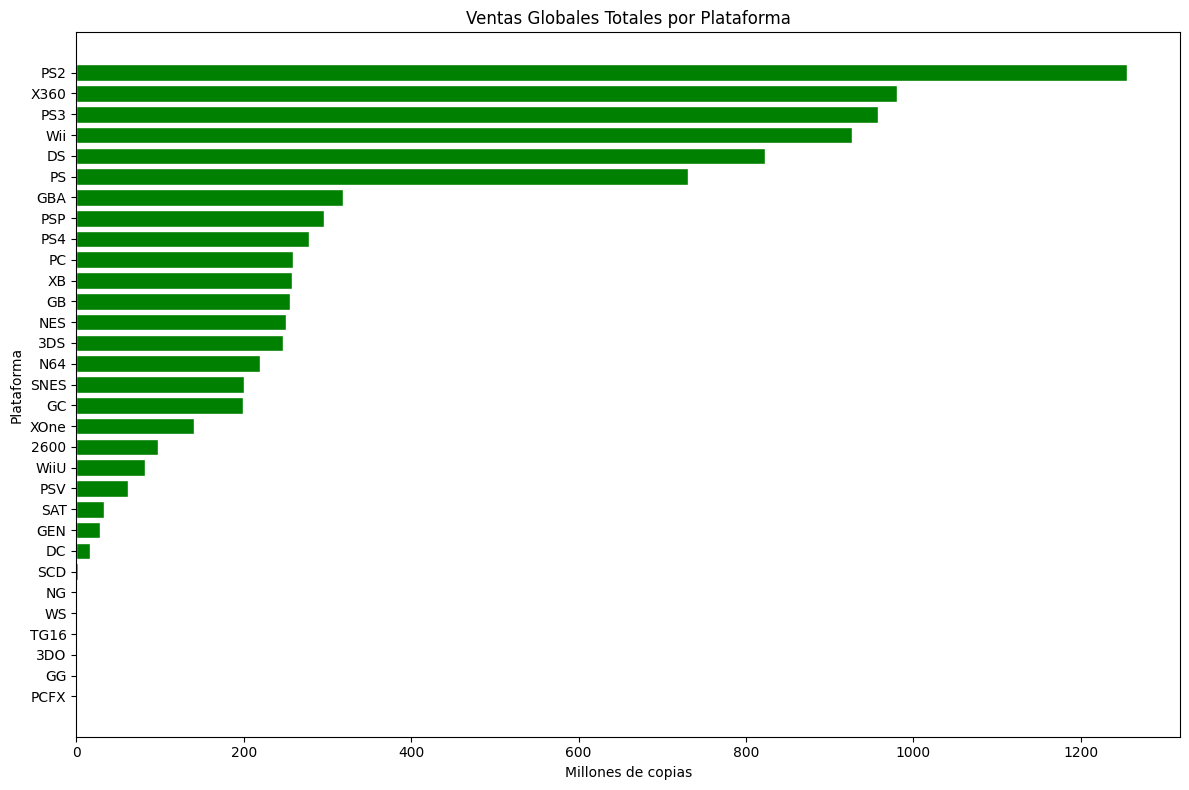

In [ ]:
ventas_plat = df.groupby('Platform')['Global_Sales'].sum().sort_values()

plt.figure(figsize=(12, 8))
plt.barh(ventas_plat.index, ventas_plat.values, color='green', edgecolor='white')
plt.title('Ventas Globales Totales por Plataforma')
plt.xlabel('Millones de copias')
plt.ylabel('Plataforma')
plt.tight_layout()
plt.show()

> El **PS2** es la plataforma con más ventas históricas, seguida por la **X360** y **PS3** que dominaron entre 2005 y 2012.

### Gráfico 3: Ventas por Año

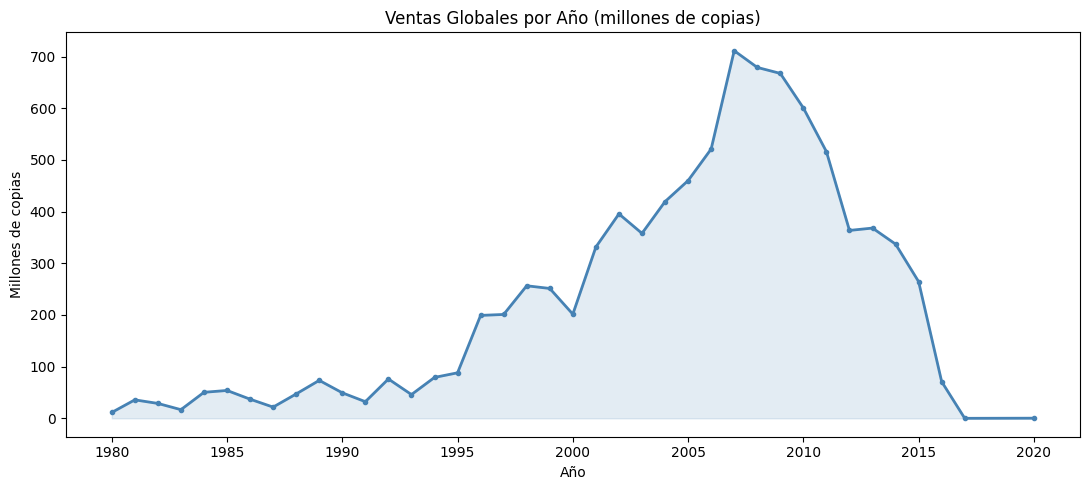

In [ ]:
ventas_año = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(11, 5))
plt.plot(ventas_año.index, ventas_año.values, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(ventas_año.index, ventas_año.values, alpha=0.15, color='steelblue')
plt.title('Ventas Globales por Año (millones de copias)')
plt.xlabel('Año')
plt.ylabel('Millones de copias')
plt.tight_layout()
plt.show()

> La industria creció hasta alcanzar su pico alrededor de **2008-2009** (era del Wii, DS y PS3). La caída posterior puede deberse a que los juegos más recientes aún no completaban su ciclo de ventas al momento de capturar los datos.

## Sección 8: Preprocesamiento

### 9.1 Eliminar columnas irrelevantes

In [ ]:
# Rank: derivado de Global_Sales, generaría fuga de datos al modelo
# Name: identificador único, no aporta valor predictivo
df_modelo = df.drop(columns=['Rank', 'Name'])
print('Columnas:', list(df_modelo.columns))

Columnas: ['Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


### 9.2 Label Encoding

In [ ]:
# Los algoritmos de ML necesitan números, no texto
# Label Encoding asigna un número entero a cada categoría
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Publisher']:
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    print(f'✅ {col} codificada')

display(df_modelo.head())

✅ Platform codificada
✅ Genre codificada
✅ Publisher codificada


,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,26,2006,10,360,41.49,29.02,3.77,8.46,82.74
1,11,1985,4,360,29.08,3.58,6.81,0.77,40.24
2,26,2008,6,360,15.85,12.88,3.79,3.31,35.82
3,26,2009,10,360,15.75,11.01,3.28,2.96,33.00
4,5,1996,7,360,11.27,8.89,10.22,1.00,31.37


### 9.3 Escalado

In [ ]:
# StandardScaler: deja todas las variables con media=0 y desviación estándar=1
# Evita que variables con rangos grandes influyan más que otras
X = df_modelo.drop(columns=['Global_Sales']).values
y = df_modelo['Global_Sales'].values

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

print(f'X: {X_scaled.shape} | y: {y.shape}')

X: (16598, 8) | y: (16598,)


## Sección 9: Mapa de correlación

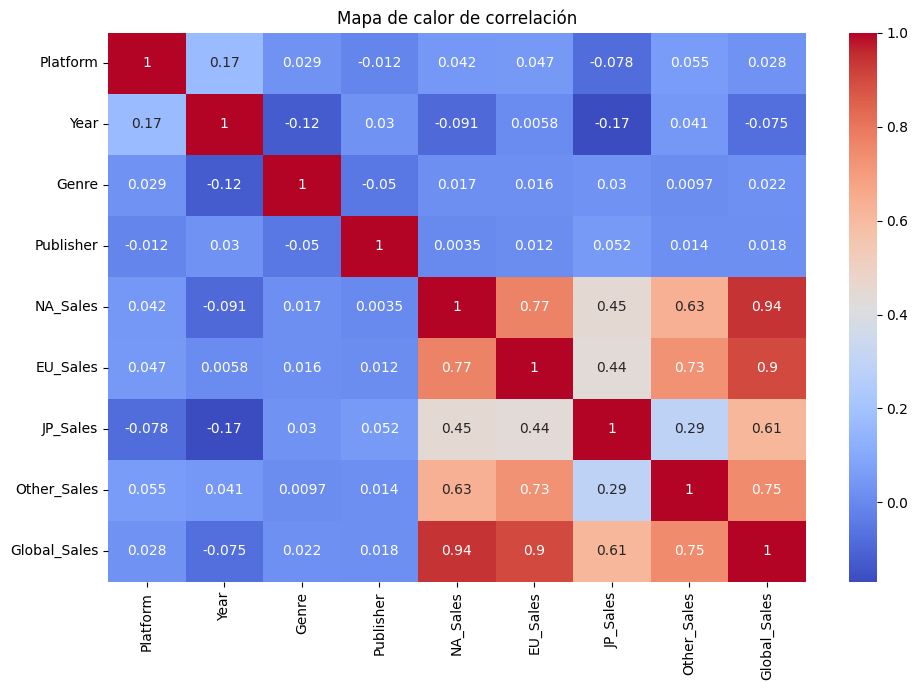

In [ ]:
# variable / dataframe / seleccionamos los tipo number / obtenemos la correlación de pearson
corr = df_modelo.select_dtypes(include='number').corr()

# filtramos variables numéricas
# corr_ejem2 = df.corr()  # aplica después del encoding de variables categóricas

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Mapa de calor de correlación')
plt.tight_layout()
plt.show()

> Las ventas de **Norteamérica** (`NA_Sales`) tienen la mayor correlación con las ventas globales, lo que refleja el peso dominante del mercado americano. Las ventas de **Japón** (`JP_Sales`) tienen menor correlación con las demás regiones, lo que indica que el mercado japonés tiene preferencias propias. El `Year` no muestra correlación relevante con las ventas.

## Sección 10: Conclusiones

A continuación, se resumen los principales hallazgos del análisis:

- Dataset con **16.598 videojuegos**, variables categóricas (Platform, Genre, Publisher) y numéricas (ventas por región).
- Nulos tratados: mediana para `Year`, categoría `'Desconocido'` para `Publisher`.
- Los outliers son juegos reales como Wii Sports o GTA V — se mantienen.
- **Action** es el género más vendido; **PS2** la plataforma con más ventas históricas.
- Norteamérica es la región con mayor influencia en las ventas globales.
- Modelo a aplicar: **regresión** para predecir `Global_Sales`.


